# Task-2: Semantic Product Search and Ranking

---

## ⚠️ **IMPORTANT: GPU RECOMMENDED**

**🚨 Before running this notebook (Google Colab):**
1. Go to **Runtime** → **Change runtime type**
2. Under **Hardware accelerator**, select **"GPU"** (T4 recommended)
3. Click **Save**
4. **Note:** The notebook will work on CPU but will be slower for BERT models

**Why GPU?** BERT-based models train much faster on GPU (10-50x speedup).  
**With GPU:** Training takes 30-60 minutes  
**Without GPU:** Training takes 3-6 hours ⏱️

**📌 For Kaggle Users:** This notebook also works on Kaggle. Just skip the Colab-specific setup cells.

**💾 Memory Optimizations for Kaggle:**
- Dataset automatically sampled to 50K samples if larger
- Word embeddings trained on sampled data (200K sentences max)
- FastText training disabled by default (can be enabled if needed)
- Reduced embedding dimensions (200 instead of 300)
- Vocabulary size limited to 50K words
- Memory cleanup after embedding generation

---

## Overview
This notebook implements a complete Semantic Product Search and Ranking system that:
- Loads and preprocesses the Amazon Shopping Queries Dataset
- Combines product title and description for rich product representation
- Applies text preprocessing (lowercase, stop words, lemmatization, special characters)
- Implements multiple text representations:
  - TF-IDF (traditional approach)
  - Word Embeddings (Word2Vec, GloVe, FastText)
  - Pretrained Transformers (BERT)
- Trains deep learning models to learn query-product relevance
- Evaluates using ranking metrics (NDCG, MAP, Precision@K, Recall@K, F1@K)
- Deploys as a web application with Gradio

## System Architecture
1. **Data Loading**: Amazon Shopping Queries Dataset from GitHub
2. **Preprocessing**: Text cleaning, normalization, lemmatization
3. **Feature Engineering**: TF-IDF, Word Embeddings, BERT embeddings
4. **Model Training**: Deep learning models for semantic relevance
5. **Evaluation**: Comprehensive ranking metrics
6. **Deployment**: Interactive web interface for real-time search


## 1. Installation and Setup


In [1]:
# Install required libraries
%pip install -q transformers torch torchvision torchaudio
%pip install -q sentence-transformers
%pip install -q gensim nltk scikit-learn
%pip install -q pandas numpy matplotlib seaborn
%pip install -q gradio
%pip install -q git+https://github.com/amazon-science/esci-data.git
%pip install -q datasets
%pip install -q requests
%pip install -q tqdm

print("\n" + "="*60)
print("✓ All libraries installed successfully!")
print("="*60)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 62.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 51.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 32.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.8 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed.

In [2]:
# Import all required libraries
import os
import json
import re
import warnings
import time
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Union
from collections import defaultdict
import pickle

warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer, 
    AutoModel,
    BertTokenizer,
    BertModel,
    get_linear_schedule_with_warmup
)
from sentence_transformers import SentenceTransformer

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
import gensim
from gensim.models import Word2Vec, FastText
from gensim.downloader import load as gensim_load

# Web Interface
import gradio as gr

# Progress bars
from tqdm.auto import tqdm
tqdm.pandas()  # Enable pandas progress bars

# Download NLTK data
try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
except:
    pass

# Detect if running on Google Colab
try:
    import google.colab
    IN_COLAB = True
    print("✓ Running on Google Colab")
except:
    IN_COLAB = False
    print("✓ Running on local/Kaggle environment")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    device = torch.device('cuda')
    print(f"✓ Using GPU: {torch.cuda.get_device_name(0)}")
    if IN_COLAB:
        print(f"✓ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    device = torch.device('cpu')
    if IN_COLAB:
        print("⚠ Using CPU - Go to Runtime → Change runtime type → GPU")
    else:
        print("⚠ Using CPU (GPU recommended for faster training)")

print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ Device: {device}")


2025-11-25 14:40:35.522763: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764081635.670146      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764081635.708609      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

✓ Running on Google Colab
✓ Using GPU: Tesla T4
✓ GPU Memory: 15.83 GB
✓ PyTorch version: 2.6.0+cu124
✓ Device: cuda


In [3]:
# ============================================================================
# MEMORY CONFIGURATION FOR KAGGLE
# ============================================================================
# Adjust these values based on your available memory
# Lower values = less memory usage, faster execution
# Higher values = better model quality, more memory needed

# Maximum dataset size (samples)
MAX_DATASET_SIZE = 80000  # Middle ground: keep most signals without exhausting RAM

# Maximum sentences for word embedding training
MAX_SENTENCES_FOR_EMBEDDINGS = 300000  # Allows richer contexts while staying manageable

# Word embedding dimensions (200-300 typical)
EMBEDDING_DIM = 256  # Compromise between 200 (light) and 300 (heavy)

# Maximum vocabulary size for Word2Vec
MAX_VOCAB_SIZE = 75000  # Larger lexicon for better coverage without going all-in

# Negative samples to create per query (forces query-aware training)
NEGATIVE_SAMPLES_PER_QUERY = 1  # Set 0 to disable negative sampling

# Enable FastText training (uses more memory)
ENABLE_FASTTEXT = True  # Set to True only if you have enough RAM (16GB+)

# TF-IDF max features
TFIDF_MAX_FEATURES = 4000  # Slight bump for improved lexical recall

print("="*60)
print("Memory Configuration")
print("="*60)
print(f"Max Dataset Size: {MAX_DATASET_SIZE:,}")
print(f"Max Sentences for Embeddings: {MAX_SENTENCES_FOR_EMBEDDINGS:,}")
print(f"Embedding Dimension: {EMBEDDING_DIM}")
print(f"Max Vocabulary Size: {MAX_VOCAB_SIZE:,}")
print(f"Negative Samples per Query: {NEGATIVE_SAMPLES_PER_QUERY}")
print(f"FastText Enabled: {ENABLE_FASTTEXT}")
print(f"TF-IDF Max Features: {TFIDF_MAX_FEATURES:,}")
print("="*60)


Memory Configuration
Max Dataset Size: 80,000
Max Sentences for Embeddings: 300,000
Embedding Dimension: 256
Max Vocabulary Size: 75,000
Negative Samples per Query: 1
FastText Enabled: True
TF-IDF Max Features: 4,000


## 📥 Dataset Setup Instructions

### For Google Colab Users:

**Option 1: Direct Download (Recommended)**
- The code will automatically download the dataset from GitHub
- No manual steps required!

**Option 2: Upload Files Manually**
1. Download the files from: https://github.com/amazon-science/esci-data/tree/main/shopping_queries_dataset
   - `shopping_queries_dataset_products.parquet`
   - `shopping_queries_dataset_examples.parquet`
2. Upload them using the file upload cell below

### For Kaggle Users:

**Option 1: Add Dataset as Kaggle Input (Recommended)**
1. Click **"Add Input"** button (top right)
2. Click **"Upload"** tab
3. Upload the `.parquet` files
4. The code will automatically detect files in `/kaggle/input/your-dataset-name/`

**Option 2: Direct Download**
- The code will attempt to download the files directly from GitHub

---

**Note:** The code handles both `.parquet` and `.jsonl` formats automatically.


## 2. Dataset Loading and Exploration


## 2. Dataset Loading and Exploration


In [4]:
# Load the Amazon Shopping Queries Dataset
# The dataset is available at: https://github.com/amazon-science/esci-data/tree/main/shopping_queries_dataset
#
# OPTION 1 (Recommended for Kaggle): Add dataset as input
#   1. Go to https://www.kaggle.com/datasets and search for "amazon shopping queries"
#   2. Or add the dataset manually:
#      - Click "Add Input" in your notebook
#      - Upload the 3 files:
#        * shopping_queries_dataset_products.parquet
#        * shopping_queries_dataset_examples.parquet
#        * shopping_queries_dataset_sources.csv (optional)
#   3. The files will be in /kaggle/input/your-dataset-name/
#
# OPTION 2: Download directly (tries multiple methods)

import urllib.request
import requests
import zipfile
import json
from pathlib import Path

# Check if dataset is already available as Kaggle input
kaggle_input_paths = [
    "/kaggle/input/amazon-shopping-queries/shopping_queries_dataset_products.parquet",
    "/kaggle/input/esci-data/shopping_queries_dataset_products.parquet",
    "/kaggle/input/shopping-queries-dataset/shopping_queries_dataset_products.parquet",
]

products_path = None
queries_path = None

# Try to find dataset in Kaggle input
for base_path in kaggle_input_paths:
    if os.path.exists(base_path):
        products_path = base_path
        queries_path = base_path.replace("products.parquet", "examples.parquet")
        print(f"✓ Found dataset in Kaggle input: {base_path}")
        break

# If not found, try current directory or download
if products_path is None:
    products_path = "shopping_queries_dataset_products.parquet"
    queries_path = "shopping_queries_dataset_examples.parquet"
    
    # Try to download using requests with proper headers
    def download_file(url, filepath, description=""):
        """Download file with retry and error handling"""
        if os.path.exists(filepath):
            print(f"✓ {description} already exists!")
            return True
        
        print(f"📥 Downloading {description}...")
        
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        }
        
        try:
            # Try with requests first (better error handling)
            response = requests.get(url, headers=headers, stream=True, timeout=60)
            if response.status_code == 200:
                total_size = int(response.headers.get('content-length', 0))
                downloaded = 0
                
                # Create progress bar
                pbar = tqdm(total=total_size, unit='B', unit_scale=True, desc=f"Downloading {description}")
                
                with open(filepath, 'wb') as f:
                    for chunk in response.iter_content(chunk_size=8192):
                        if chunk:
                            f.write(chunk)
                            downloaded += len(chunk)
                            pbar.update(len(chunk))
                
                pbar.close()
                print(f"✓ {description} downloaded successfully! ({downloaded / 1024 / 1024:.2f} MB)")
                return True
            else:
                print(f"⚠ HTTP {response.status_code} error")
                return False
        except Exception as e:
            print(f"⚠ Error: {e}")
            return False
    
    # Correct GitHub URLs (using .parquet files)
    dataset_url = "https://github.com/amazon-science/esci-data/raw/main/shopping_queries_dataset/shopping_queries_dataset_products.parquet"
    queries_url = "https://github.com/amazon-science/esci-data/raw/main/shopping_queries_dataset/shopping_queries_dataset_examples.parquet"
    
    # Download products
    if not os.path.exists(products_path):
        if not download_file(dataset_url, products_path, "products dataset"):
            print("\n⚠ Could not download products dataset.")
            print("💡 RECOMMENDED: Add the dataset as a Kaggle input instead!")
            print("   1. Download the files from: https://github.com/amazon-science/esci-data/tree/main/shopping_queries_dataset")
            print("   2. In your Kaggle notebook, click 'Add Input'")
            print("   3. Upload the .parquet files")
            print("   4. Update the paths in the code to point to /kaggle/input/your-dataset-name/")
            # Create minimal sample for demonstration
            print("\n⚠ Creating minimal sample dataset for demonstration...")
            import pandas as pd
            sample_products = pd.DataFrame({
                'product_id': [f'prod_{i}' for i in range(50)],
                'product_title': [f'Sample Product {i}' for i in range(50)],
                'product_description': [f'Description for product {i}' for i in range(50)]
            })
            sample_products.to_parquet(products_path, index=False)
            print("✓ Sample products dataset created!")
    
    # Download queries
    if not os.path.exists(queries_path):
        if not download_file(queries_url, queries_path, "query-product pairs"):
            print("⚠ Query-product pairs file not available. Will create from products dataset.")

# Set final paths
dataset_path = products_path
queries_path = queries_path

print("\n" + "="*60)
print("Dataset files ready!")
print(f"Products: {dataset_path}")
print(f"Queries: {queries_path}")
print("="*60)


📥 Downloading products dataset...


✓ products dataset downloaded successfully! (1057.49 MB)
📥 Downloading query-product pairs...


✓ query-product pairs downloaded successfully! (48.91 MB)

Dataset files ready!
Products: shopping_queries_dataset_products.parquet
Queries: shopping_queries_dataset_examples.parquet


In [5]:
# Load products data (handle both .parquet and .jsonl formats)
print("Loading products data...")
if dataset_path.endswith('.parquet'):
    products_df = pd.read_parquet(dataset_path)
    print(f"✓ Loaded {len(products_df)} products from parquet file")
elif dataset_path.endswith('.jsonl'):
    products = []
    # Get file size for progress bar
    file_size = os.path.getsize(dataset_path)
    with open(dataset_path, 'r', encoding='utf-8') as f:
        with tqdm(total=file_size, unit='B', unit_scale=True, desc="Loading JSONL file") as pbar:
            for line in f:
                products.append(json.loads(line.strip()))
                pbar.update(len(line.encode('utf-8')))
    products_df = pd.DataFrame(products)
    print(f"✓ Loaded {len(products_df)} products from jsonl file")
else:
    # Try parquet first, then jsonl
    try:
        products_df = pd.read_parquet(dataset_path)
        print(f"✓ Loaded {len(products_df)} products from parquet file")
    except:
        products = []
        # Get file size for progress bar
        file_size = os.path.getsize(dataset_path)
        with open(dataset_path, 'r', encoding='utf-8') as f:
            with tqdm(total=file_size, unit='B', unit_scale=True, desc="Loading JSONL file") as pbar:
                for line in f:
                    products.append(json.loads(line.strip()))
                    pbar.update(len(line.encode('utf-8')))
        products_df = pd.DataFrame(products)
        print(f"✓ Loaded {len(products_df)} products from jsonl file")

# Load query-product pairs
print("\nLoading query-product pairs...")
if os.path.exists(queries_path):
    try:
        queries_df = pd.read_parquet(queries_path)
        print(f"✓ Loaded {len(queries_df)} query-product pairs")
    except Exception as e:
        print(f"⚠ Could not load parquet file: {e}")
        print("Creating synthetic query-product pairs from products...")
        queries_df = None
else:
    print("⚠ Query-product pairs file not found. Creating synthetic pairs...")
    queries_df = None

# If queries_df is None, create synthetic query-product pairs
if queries_df is None:
    print("Generating synthetic query-product pairs...")
    # Create realistic queries based on product titles
    synthetic_queries = []
    query_templates = [
        "best {keyword}",
        "{keyword} for sale",
        "buy {keyword}",
        "{keyword} review",
        "cheap {keyword}",
        "{keyword} online",
        "top rated {keyword}",
        "{keyword} discount"
    ]
    
    # Extract keywords from product titles with progress bar
    for idx, row in tqdm(products_df.iterrows(), total=len(products_df), desc="Generating synthetic queries"):
        title = str(row.get('product_title', row.get('title', f'Product {idx}')))
        # Simple keyword extraction (first few words)
        keywords = title.lower().split()[:3]
        keyword = ' '.join(keywords)
        
        # Create multiple queries per product
        for template in query_templates[:3]:  # Use first 3 templates
            query = template.format(keyword=keyword)
            synthetic_queries.append({
                'query': query,
                'product_id': row.get('product_id', f'prod_{idx}'),
                'product_locale': 'US',
                'esci_label': 'E' if np.random.random() > 0.3 else 'S'  # E=Exact, S=Substitute
            })
    
    queries_df = pd.DataFrame(synthetic_queries)
    print(f"✓ Created {len(queries_df)} synthetic query-product pairs")

# Display basic information
print("\n" + "="*60)
print("Dataset Overview")
print("="*60)
print(f"\nProducts DataFrame Shape: {products_df.shape}")
print(f"Products Columns: {list(products_df.columns)}")
print(f"\nQueries DataFrame Shape: {queries_df.shape}")
print(f"Queries Columns: {list(queries_df.columns)}")

# Show sample data
print("\n" + "="*60)
print("Sample Product Data")
print("="*60)
print(products_df.head(3))

print("\n" + "="*60)
print("Sample Query-Product Pairs")
print("="*60)
print(queries_df.head(3))


Loading products data...
✓ Loaded 1814924 products from parquet file

Loading query-product pairs...
✓ Loaded 2621288 query-product pairs

Dataset Overview

Products DataFrame Shape: (1814924, 7)
Products Columns: ['product_id', 'product_title', 'product_description', 'product_bullet_point', 'product_brand', 'product_color', 'product_locale']

Queries DataFrame Shape: (2621288, 9)
Queries Columns: ['example_id', 'query', 'query_id', 'product_id', 'product_locale', 'esci_label', 'small_version', 'large_version', 'split']

Sample Product Data
   product_id                                      product_title  \
0  B079VKKJN7  11 Degrees de los Hombres Playera con Logo, Ne...   
1  B079Y9VRKS          Camiseta Eleven Degrees Core TS White (M)   
2  B07DP4LM9H  11 Degrees de los Hombres Core Pull Over Hoodi...   

                                 product_description  \
0  Esta playera con el logo de la marca Carrier d...   
1                                               None   
2  La sudade

In [6]:
# Merge products with queries to get full information
# First, let's understand the data structure better

print("Analyzing data structure...")
print("\nProduct columns:", products_df.columns.tolist())
print("\nQuery columns:", queries_df.columns.tolist())

# Check for product_id or similar key to merge
if 'product_id' in products_df.columns and 'product_id' in queries_df.columns:
    merge_key = 'product_id'
elif 'product_locale' in products_df.columns and 'product_id' in queries_df.columns:
    # Some datasets use locale + product_id combination
    if 'product_locale' in queries_df.columns:
        products_df['merge_key'] = products_df['product_locale'] + '_' + products_df['product_id'].astype(str)
        queries_df['merge_key'] = queries_df['product_locale'] + '_' + queries_df['product_id'].astype(str)
        merge_key = 'merge_key'
    else:
        merge_key = 'product_id'
else:
    # Try to find common columns
    common_cols = set(products_df.columns) & set(queries_df.columns)
    print(f"\nCommon columns: {common_cols}")
    if common_cols:
        merge_key = list(common_cols)[0]
    else:
        # If no common key, we'll work with what we have
        merge_key = None

print(f"\nUsing merge key: {merge_key}")

# Create a combined dataset
if merge_key:
    combined_df = queries_df.merge(products_df, on=merge_key, how='left', suffixes=('', '_product'))
else:
    # If we can't merge, use queries_df and try to get product info separately
    combined_df = queries_df.copy()
    # Create a product lookup dictionary
    if 'product_id' in products_df.columns:
        product_dict = products_df.set_index('product_id').to_dict('index')
    else:
        product_dict = {}

print(f"\n✓ Combined dataset shape: {combined_df.shape}")
print(f"✓ Combined dataset columns: {list(combined_df.columns)[:10]}...")  # Show first 10


Analyzing data structure...

Product columns: ['product_id', 'product_title', 'product_description', 'product_bullet_point', 'product_brand', 'product_color', 'product_locale']

Query columns: ['example_id', 'query', 'query_id', 'product_id', 'product_locale', 'esci_label', 'small_version', 'large_version', 'split']

Using merge key: product_id

✓ Combined dataset shape: (2680364, 15)
✓ Combined dataset columns: ['example_id', 'query', 'query_id', 'product_id', 'product_locale', 'esci_label', 'small_version', 'large_version', 'split', 'product_title']...


In [7]:
# Prepare the dataset: combine product title and description
# Find the relevant columns

def find_column(df, keywords):
    """Find column name containing any of the keywords"""
    for col in df.columns:
        col_lower = col.lower()
        if any(keyword in col_lower for keyword in keywords):
            return col
    return None

# Find query column
query_col = find_column(combined_df, ['query', 'search'])
if query_col is None:
    query_col = combined_df.columns[0]  # Use first column as fallback

# Find product title column
title_col = find_column(combined_df, ['title', 'product_title', 'name'])
if title_col is None:
    title_col = find_column(products_df, ['title', 'product_title', 'name'])

# Find product description column
desc_col = find_column(combined_df, ['description', 'product_description', 'detail'])
if desc_col is None:
    desc_col = find_column(products_df, ['description', 'product_description', 'detail'])

# Find relevance label column
label_col = find_column(combined_df, ['relevance', 'label', 'esci_label', 'grade'])

print("Column Mapping:")
print(f"  Query: {query_col}")
print(f"  Title: {title_col}")
print(f"  Description: {desc_col}")
print(f"  Label: {label_col}")

# Create a clean dataset
data = []

for idx, row in tqdm(combined_df.iterrows(), total=len(combined_df), desc="Creating clean dataset"):
    query = str(row[query_col]) if query_col and pd.notna(row[query_col]) else ""
    
    # Get product title
    if title_col and title_col in row and pd.notna(row[title_col]):
        title = str(row[title_col])
    else:
        title = ""
    
    # Get product description
    if desc_col and desc_col in row and pd.notna(row[desc_col]):
        description = str(row[desc_col])
    else:
        description = ""
    
    # Combine title and description
    product_text = f"{title} {description}".strip()
    
    # Track product identifiers when available
    product_id = None
    if 'product_id' in row and pd.notna(row['product_id']):
        product_id = str(row['product_id'])
    elif 'product_id_product' in row and pd.notna(row['product_id_product']):
        product_id = str(row['product_id_product'])
    else:
        product_id = f"prod_{idx}"
    
    # Get relevance label
    if label_col and label_col in row and pd.notna(row[label_col]):
        label = str(row[label_col])
        # Convert ESCI labels to binary (E=Exact, S=Substitute are relevant)
        if label in ['E', 'Exact', '1', 1]:
            relevance = 1
        elif label in ['S', 'Substitute', '0.5']:
            relevance = 0.5
        else:
            relevance = 0
    else:
        relevance = 1  # Default to relevant if no label
    
    if query and product_text:
        data.append({
            'query': query,
            'product_id': product_id,
            'product_title': title,
            'product_description': description,
            'product_text': product_text,  # Combined title + description
            'relevance': relevance
        })

df = pd.DataFrame(data)
print(f"\n✓ Created dataset with {len(df)} query-product pairs")

# MEMORY OPTIMIZATION: Limit dataset size for Kaggle
# Uses MAX_DATASET_SIZE from configuration cell
if len(df) > MAX_DATASET_SIZE:
    print(f"\n⚠ Dataset is large ({len(df):,} samples). Sampling to {MAX_DATASET_SIZE:,} for memory efficiency...")
    # Stratified sampling to maintain relevance distribution
    df = df.groupby('relevance', group_keys=False).apply(
        lambda x: x.sample(min(len(x), int(MAX_DATASET_SIZE * len(x) / len(df))))
    ).reset_index(drop=True)
    print(f"✓ Sampled dataset: {len(df):,} samples")

print(f"✓ Relevance distribution:")
print(df['relevance'].value_counts().sort_index())

# Show sample
print("\n" + "="*60)
print("Sample Data")
print("="*60)
print(df.head(3))


Column Mapping:
  Query: query
  Title: product_title
  Description: product_description
  Label: esci_label


Creating clean dataset:   0%|          | 0/2680364 [00:00<?, ?it/s]


✓ Created dataset with 2680364 query-product pairs

⚠ Dataset is large (2,680,364 samples). Sampling to 80,000 for memory efficiency...
✓ Sampled dataset: 79,999 samples
✓ Relevance distribution:
relevance
0.0    10372
0.5    17572
1.0    52055
Name: count, dtype: int64

Sample Data
                                               query  product_id  \
0                                            風に消えないで  4778321898   
1  A new black jacket for the spring/summer seaso...  B07L4V9MZL   
2                                        pool heater  B078P7L1J7   

                                       product_title  \
0                                            8月のソーダ水   
1  ANJUNIE Warm Winter Jacket Women's Curved Hem ...   
2  Immersion Heater, Kingwork UL-Listed Pool Heat...   

                                 product_description  \
0                                                      
1  ♫♫<b>size: Our size is based on Asians. It is ...   
2  - The Kingwork bucket heater designed to heat 

In [8]:
# Add negative samples so the model sees non-matching query-product pairs
if NEGATIVE_SAMPLES_PER_QUERY > 0:
    print("\n" + "="*60)
    print("Negative Sampling")
    print("="*60)
    
    # Build a clean product pool to sample from
    product_pool = df[['product_id', 'product_title', 'product_description', 'product_text']].copy()
    product_pool['product_text'] = product_pool['product_text'].fillna('').astype(str)
    product_pool = product_pool.drop_duplicates(subset='product_id').reset_index(drop=True)
    product_pool = product_pool[product_pool['product_text'].str.strip() != ""]
    product_pool = product_pool.reset_index(drop=True)
    product_lookup = product_pool.set_index('product_id').to_dict('index')
    product_ids = list(product_lookup.keys())
    
    # Group positives per query for quick lookup
    positive_map = df.groupby('query')['product_id'].apply(lambda x: set(x)).to_dict()
    
    rng = np.random.default_rng(42)
    negatives = []
    
    for query, positive_ids in tqdm(positive_map.items(), desc="Sampling negatives"):
        available_ids = [pid for pid in product_ids if pid not in positive_ids]
        if not available_ids:
            continue
        sample_size = min(NEGATIVE_SAMPLES_PER_QUERY, len(available_ids))
        sampled = rng.choice(available_ids, size=sample_size, replace=False)
        for pid in sampled:
            prod = product_lookup[pid]
            negatives.append({
                'query': query,
                'product_id': pid,
                'product_title': prod['product_title'],
                'product_description': prod['product_description'],
                'product_text': prod['product_text'],
                'relevance': 0.0
            })
    
    if negatives:
        negatives_df = pd.DataFrame(negatives)
        print(f"✓ Generated {len(negatives_df):,} hard negatives")
        df = pd.concat([df, negatives_df], ignore_index=True)
        df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)
        print(f"✓ Dataset size after negatives: {len(df):,}")
    else:
        print("⚠ No negatives were generated (insufficient product pool)")
else:
    print("⏭ Negative sampling disabled (NEGATIVE_SAMPLES_PER_QUERY=0)")



Negative Sampling


Sampling negatives:   0%|          | 0/57758 [00:00<?, ?it/s]

✓ Generated 57,758 hard negatives
✓ Dataset size after negatives: 137,757


## 3. Text Preprocessing

Implementing text preprocessing steps:
- Convert to lowercase
- Remove stop words
- Apply lemmatization
- Remove special characters


In [9]:
# Initialize preprocessing tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    """
    Preprocess text: lowercase, remove special chars, stopwords, lemmatize
    """
    if pd.isna(text) or text == "":
        return ""
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove special characters and digits, keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords if requested
    if remove_stopwords:
        tokens = [token for token in tokens if token not in stop_words]
    
    # Lemmatize if requested
    if lemmatize:
        tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    # Join back to string
    processed_text = ' '.join(tokens)
    
    return processed_text

# Apply preprocessing with progress bars
print("Preprocessing queries and products...")
print(f"Total rows to process: {len(df):,}\n")

# Process each column with progress bar
print("Processing queries...")
df['query_processed'] = df['query'].progress_apply(lambda x: preprocess_text(x))

print("\nProcessing product text (title + description)...")
df['product_text_processed'] = df['product_text'].progress_apply(lambda x: preprocess_text(x))

print("\nProcessing product titles...")
df['product_title_processed'] = df['product_title'].progress_apply(lambda x: preprocess_text(x))

print("\nProcessing product descriptions...")
df['product_description_processed'] = df['product_description'].progress_apply(lambda x: preprocess_text(x))

print("\n" + "="*60)
print("✓ Preprocessing complete!")
print("="*60)
print("\nSample preprocessed data:")
print(f"Original query: {df['query'].iloc[0]}")
print(f"Processed query: {df['query_processed'].iloc[0]}")
print(f"\nOriginal product: {df['product_text'].iloc[0][:100]}...")
print(f"Processed product: {df['product_text_processed'].iloc[0][:100]}...")


Preprocessing queries and products...
Total rows to process: 137,757

Processing queries...


  0%|          | 0/137757 [00:00<?, ?it/s]


Processing product text (title + description)...


  0%|          | 0/137757 [00:00<?, ?it/s]


Processing product titles...


  0%|          | 0/137757 [00:00<?, ?it/s]


Processing product descriptions...


  0%|          | 0/137757 [00:00<?, ?it/s]


✓ Preprocessing complete!

Sample preprocessed data:
Original query: special victims unit
Processed query: special victim unit

Original product: Know It All...
Processed product: know...


## 4. Text Representation Methods

Implementing three approaches:
1. **TF-IDF**: Traditional bag-of-words approach
2. **Word Embeddings**: Word2Vec, GloVe, FastText
3. **Pretrained Transformers**: BERT


In [10]:
# 4.1 TF-IDF Vectorization
print("="*60)
print("4.1 TF-IDF Vectorization")
print("="*60)

# Combine all text for fitting TF-IDF
print("Combining text data...")
all_text = list(df['query_processed']) + list(df['product_text_processed'])

# Create TF-IDF vectorizer (optimized for memory)
tfidf_vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,  # From configuration cell
    ngram_range=(1, 2),  # Unigrams and bigrams
    min_df=3,  # Increased minimum document frequency to reduce vocabulary
    max_df=0.95  # Maximum document frequency
)

print("Fitting TF-IDF vectorizer...")
with tqdm(total=1, desc="Fitting TF-IDF") as pbar:
    tfidf_vectorizer.fit(all_text)
    pbar.update(1)

# Transform queries and products
print("Transforming queries and products...")
with tqdm(total=2, desc="Transforming text") as pbar:
    query_tfidf = tfidf_vectorizer.transform(df['query_processed'])
    pbar.update(1)
    product_tfidf = tfidf_vectorizer.transform(df['product_text_processed'])
    pbar.update(1)

print(f"✓ TF-IDF shape for queries: {query_tfidf.shape}")
print(f"✓ TF-IDF shape for products: {product_tfidf.shape}")
print(f"✓ Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")


4.1 TF-IDF Vectorization
Combining text data...
Fitting TF-IDF vectorizer...


Fitting TF-IDF:   0%|          | 0/1 [00:00<?, ?it/s]

Transforming queries and products...


Transforming text:   0%|          | 0/2 [00:00<?, ?it/s]

✓ TF-IDF shape for queries: (137757, 4000)
✓ TF-IDF shape for products: (137757, 4000)
✓ Vocabulary size: 4000


In [11]:
# 4.2 Word Embeddings (Word2Vec, GloVe, FastText)
print("="*60)
print("4.2 Word Embeddings (Memory-Optimized)")
print("="*60)

# MEMORY OPTIMIZATION: Sample sentences for training embeddings
# Training on full dataset creates huge vocabulary and uses too much memory
MAX_SENTENCES_FOR_EMBEDDINGS = 200000  # Limit to 200K sentences
print(f"⚠ Memory optimization: Sampling sentences for embedding training...")

# Prepare tokenized text for word embeddings (with sampling)
print("Tokenizing text for word embeddings...")
all_sentences = []
for text in tqdm(all_text, desc="Tokenizing sentences"):
    if text:
        tokens = word_tokenize(text.lower())
        if len(tokens) > 0:  # Only add non-empty sentences
            all_sentences.append(tokens)

print(f"Total sentences before sampling: {len(all_sentences):,}")

# Sample sentences if dataset is too large
if len(all_sentences) > MAX_SENTENCES_FOR_EMBEDDINGS:
    print(f"Sampling {MAX_SENTENCES_FOR_EMBEDDINGS:,} sentences for memory efficiency...")
    import random
    random.seed(42)
    all_sentences = random.sample(all_sentences, MAX_SENTENCES_FOR_EMBEDDINGS)
    print(f"✓ Sampled to {len(all_sentences):,} sentences")

print(f"Total sentences for training embeddings: {len(all_sentences):,}")

# Train Word2Vec (with memory-optimized settings)
print("\nTraining Word2Vec (memory-optimized)...")
with tqdm(total=1, desc="Training Word2Vec") as pbar:
    word2vec_model = Word2Vec(
        sentences=all_sentences,
        vector_size=EMBEDDING_DIM,  # From configuration
        window=5,
        min_count=5,  # Increased from 2 to reduce vocabulary size significantly
        workers=2,  # Reduced workers to save memory
        sg=0,  # CBOW
        max_vocab_size=MAX_VOCAB_SIZE  # From configuration
    )
    pbar.update(1)
print(f"✓ Word2Vec trained with vocabulary size: {len(word2vec_model.wv):,}")

# Skip FastText training (too memory-intensive for Kaggle)
# Use pretrained GloVe instead which is more memory-efficient
SKIP_FASTTEXT = False  # Set to False if you have enough memory
if not SKIP_FASTTEXT:
    print("\nTraining FastText (this may use significant memory)...")
    try:
        with tqdm(total=1, desc="Training FastText") as pbar:
            fasttext_model = FastText(
                sentences=all_sentences,
                vector_size=EMBEDDING_DIM,  # From configuration
                window=5,
                min_count=5,  # Increased min_count
                workers=2,
                sg=0,
                max_vocab_size=MAX_VOCAB_SIZE  # From configuration
            )
            pbar.update(1)
        print(f"✓ FastText trained with vocabulary size: {len(fasttext_model.wv):,}")
    except MemoryError:
        print("⚠ FastText training failed due to memory constraints. Skipping...")
        SKIP_FASTTEXT = True
        fasttext_model = None
else:
    print("\n⏭ Skipping FastText training (memory optimization)")
    fasttext_model = None

# Load GloVe (pretrained - memory efficient)
print("\nLoading GloVe embeddings (pretrained, memory-efficient)...")
try:
    with tqdm(total=1, desc="Loading GloVe") as pbar:
        glove_model = gensim_load('glove-wiki-gigaword-200')  # Use 200-dim instead of 300
        pbar.update(1)
    print(f"✓ GloVe loaded with vocabulary size: {len(glove_model):,}")
except Exception as e:
    print(f"⚠ Could not load GloVe: {e}")
    print("Using Word2Vec as fallback for GloVe")
    glove_model = word2vec_model.wv

# Helper utilities to ensure fixed-size sentence embeddings

def infer_embedding_dim(embedding_model, default_dim=EMBEDDING_DIM):
    """Infer embedding dimensionality with safe fallbacks."""
    if hasattr(embedding_model, 'vector_size'):
        return embedding_model.vector_size
    if hasattr(embedding_model, 'wv') and hasattr(embedding_model.wv, 'vector_size'):
        return embedding_model.wv.vector_size
    return default_dim


def get_sentence_embedding(text, embedding_model, dim=None):
    """Average word embeddings to get a fixed-size sentence embedding."""
    target_dim = dim or infer_embedding_dim(embedding_model)
    text = '' if text is None else str(text)
    tokens = word_tokenize(text.lower())
    embeddings = []

    for token in tokens:
        try:
            if hasattr(embedding_model, '__contains__') and token in embedding_model:
                embeddings.append(np.asarray(embedding_model[token], dtype=np.float32))
            elif hasattr(embedding_model, 'wv') and token in embedding_model.wv:
                embeddings.append(np.asarray(embedding_model.wv[token], dtype=np.float32))
        except KeyError:
            continue

    if not embeddings:
        return np.zeros(target_dim, dtype=np.float32)

    return np.mean(np.stack(embeddings), axis=0)


def build_sentence_embeddings(texts, embedding_model, desc):
    """Vectorize an iterable of texts with consistent shapes."""
    texts = ['' if t is None else str(t) for t in texts]
    dim = infer_embedding_dim(embedding_model)
    embeddings = np.zeros((len(texts), dim), dtype=np.float32)

    for idx, text in enumerate(tqdm(texts, desc=desc)):
        embeddings[idx] = get_sentence_embedding(text, embedding_model, dim)

    return embeddings

# Create embeddings for queries and products (batch processing for memory efficiency)
print("\nCreating sentence embeddings...")
print("Creating Word2Vec embeddings...")
query_w2v = build_sentence_embeddings(df['query_processed'], word2vec_model.wv, "Query W2V embeddings")
product_w2v = build_sentence_embeddings(df['product_text_processed'], word2vec_model.wv, "Product W2V embeddings")

if fasttext_model is not None:
    print("Creating FastText embeddings...")
    query_ft = build_sentence_embeddings(df['query_processed'], fasttext_model.wv, "Query FastText embeddings")
    product_ft = build_sentence_embeddings(df['product_text_processed'], fasttext_model.wv, "Product FastText embeddings")
else:
    print("⏭ Skipping FastText embeddings (memory optimization)")
    query_ft = query_w2v.copy()  # Use Word2Vec as fallback
    product_ft = product_w2v.copy()

print("Creating GloVe embeddings...")
query_glove = build_sentence_embeddings(df['query_processed'], glove_model, "Query GloVe embeddings")
product_glove = build_sentence_embeddings(df['product_text_processed'], glove_model, "Product GloVe embeddings")

print(f"✓ Word2Vec embeddings shape: {query_w2v.shape}")
print(f"✓ FastText embeddings shape: {query_ft.shape}")
print(f"✓ GloVe embeddings shape: {query_glove.shape}")

# Free up memory
del all_sentences
import gc
gc.collect()
print("✓ Memory cleaned up")


4.2 Word Embeddings (Memory-Optimized)
⚠ Memory optimization: Sampling sentences for embedding training...
Tokenizing text for word embeddings...


Tokenizing sentences:   0%|          | 0/275514 [00:00<?, ?it/s]

Total sentences before sampling: 254,293
Sampling 200,000 sentences for memory efficiency...
✓ Sampled to 200,000 sentences
Total sentences for training embeddings: 200,000

Training Word2Vec (memory-optimized)...


Training Word2Vec:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Word2Vec trained with vocabulary size: 24,225

Training FastText (this may use significant memory)...


...

Product FastText embeddings:   0%|          | 0/137757 [00:00<?, ?it/s]

Creating GloVe embeddings...


Query GloVe embeddings:   0%|          | 0/137757 [00:00<?, ?it/s]

Product GloVe embeddings:   0%|          | 0/137757 [00:00<?, ?it/s]

✓ Word2Vec embeddings shape: (137757, 256)
✓ FastText embeddings shape: (137757, 256)
✓ GloVe embeddings shape: (137757, 200)
✓ Memory cleaned up


In [12]:
# 4.3 BERT Embeddings (Pretrained Transformer)
print("="*60)
print("4.3 BERT Embeddings")
print("="*60)

# Load BERT model and tokenizer
bert_model_name = 'bert-base-uncased'
print(f"Loading BERT model: {bert_model_name}...")

print("Loading tokenizer...")
bert_tokenizer = BertTokenizer.from_pretrained(bert_model_name)
print("✓ Tokenizer loaded")

print("Loading BERT model (this may take a while)...")
with tqdm(total=1, desc="Loading BERT model") as pbar:
    bert_model = BertModel.from_pretrained(bert_model_name).to(device)
    bert_model.eval()
    pbar.update(1)

print("✓ BERT model loaded")

# Function to get BERT embeddings in true batches (much faster)
def get_bert_embeddings_batch(texts, tokenizer, model, batch_size=32, max_length=128, desc="Processing"):
    """Get BERT embeddings in batches - optimized version"""
    embeddings = []
    texts = [str(text) for text in texts]  # Convert to strings
    
    num_batches = (len(texts) + batch_size - 1) // batch_size
    
    with tqdm(total=len(texts), unit="texts", desc=desc) as pbar:
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            
            # Tokenize entire batch at once
            encoded = tokenizer(
                batch_texts,
                max_length=max_length,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
            
            # Move to device
            encoded = {k: v.to(device) for k, v in encoded.items()}
            
            # Get embeddings for entire batch
            with torch.no_grad():
                outputs = model(**encoded)
                # Use [CLS] token embedding (first token) for each item in batch
                batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            
            embeddings.extend(batch_embeddings)
            pbar.update(len(batch_texts))
    
    return np.array(embeddings)

# Create BERT embeddings (batch processing for efficiency)
print("\nCreating BERT embeddings (this may take a while)...")
batch_size = 32

# Get embeddings for queries and products
print("Processing queries...")
query_bert = get_bert_embeddings_batch(df['query'].values, bert_tokenizer, bert_model, batch_size, desc="Query BERT embeddings")

print("Processing products...")
product_bert = get_bert_embeddings_batch(df['product_text'].values, bert_tokenizer, bert_model, batch_size, desc="Product BERT embeddings")

print(f"✓ BERT embeddings shape: {query_bert.shape}")
print(f"✓ BERT embedding dimension: {query_bert.shape[1]}")


4.3 BERT Embeddings
Loading BERT model: bert-base-uncased...
Loading tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

✓ BERT model loaded

Creating BERT embeddings (this may take a while)...
Processing queries...


Query BERT embeddings:   0%|          | 0/137757 [00:00<?, ?texts/s]

Processing products...


Product BERT embeddings:   0%|          | 0/137757 [00:00<?, ?texts/s]

✓ BERT embeddings shape: (137757, 768)
✓ BERT embedding dimension: 768


## 5. Dataset Splitting

Split into training (70%), validation (15%), and test (15%) sets.


In [13]:
# Split dataset: 70% train, 15% validation, 15% test
print("Splitting dataset...")

# First split: 70% train, 30% temp (for val + test)
train_df, temp_df = train_test_split(
    df, 
    test_size=0.30, 
    random_state=42,
    stratify=df['relevance'] if len(df['relevance'].unique()) > 1 else None
)

# Second split: 15% validation, 15% test (from 30%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['relevance'] if len(temp_df['relevance'].unique()) > 1 else None
)

print(f"✓ Training set: {len(train_df)} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"✓ Validation set: {len(val_df)} samples ({len(val_df)/len(df)*100:.1f}%)")
print(f"✓ Test set: {len(test_df)} samples ({len(test_df)/len(df)*100:.1f}%)")

# Create indices for splitting embeddings
train_indices = train_df.index.values
val_indices = val_df.index.values
test_indices = test_df.index.values

print("\n✓ Dataset split complete!")


Splitting dataset...
✓ Training set: 96429 samples (70.0%)
✓ Validation set: 20664 samples (15.0%)
✓ Test set: 20664 samples (15.0%)

✓ Dataset split complete!


## 6. Deep Learning Model Architecture

Building a neural network to learn semantic relevance between queries and products.


In [14]:
# Define PyTorch Dataset class
class ProductSearchDataset(Dataset):
    def __init__(self, queries, products, labels):
        self.queries = queries
        self.products = products
        self.labels = labels
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return {
            'query': self.queries[idx],
            'product': self.products[idx],
            'label': self.labels[idx]
        }

# Define Neural Network Model for Semantic Relevance
class SemanticRelevanceModel(nn.Module):
    def __init__(self, input_dim, hidden_dims=[512, 256, 128], dropout=0.3):
        super(SemanticRelevanceModel, self).__init__()
        
        # Query encoder
        query_layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            query_layers.append(nn.Linear(prev_dim, hidden_dim))
            query_layers.append(nn.ReLU())
            query_layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        self.query_encoder = nn.Sequential(*query_layers)
        
        # Product encoder (same architecture)
        product_layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            product_layers.append(nn.Linear(prev_dim, hidden_dim))
            product_layers.append(nn.ReLU())
            product_layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        self.product_encoder = nn.Sequential(*product_layers)
        
        # Similarity computation layers
        self.similarity_layers = nn.Sequential(
            nn.Linear(hidden_dims[-1] * 2, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    
    def forward(self, query_emb, product_emb):
        # Encode query and product
        query_encoded = self.query_encoder(query_emb)
        product_encoded = self.product_encoder(product_emb)
        
        # Concatenate for similarity computation
        combined = torch.cat([query_encoded, product_encoded], dim=1)
        
        # Compute relevance score
        relevance_score = self.similarity_layers(combined)
        
        return relevance_score.squeeze()

print("✓ Model architecture defined!")


✓ Model architecture defined!


In [15]:
# Prepare data for BERT-based model (we'll use BERT as it's the most powerful)
# Convert to tensors
print("Preparing data for training...")

# Use BERT embeddings for the main model
X_query_train = torch.FloatTensor(query_bert[train_indices])
X_product_train = torch.FloatTensor(product_bert[train_indices])
y_train = torch.FloatTensor(train_df['relevance'].values)

X_query_val = torch.FloatTensor(query_bert[val_indices])
X_product_val = torch.FloatTensor(product_bert[val_indices])
y_val = torch.FloatTensor(val_df['relevance'].values)

X_query_test = torch.FloatTensor(query_bert[test_indices])
X_product_test = torch.FloatTensor(product_bert[test_indices])
y_test = torch.FloatTensor(test_df['relevance'].values)

# Create datasets
train_dataset = ProductSearchDataset(X_query_train, X_product_train, y_train)
val_dataset = ProductSearchDataset(X_query_val, X_product_val, y_val)
test_dataset = ProductSearchDataset(X_query_test, X_product_test, y_test)

# Create data loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"✓ Training batches: {len(train_loader)}")
print(f"✓ Validation batches: {len(val_loader)}")
print(f"✓ Test batches: {len(test_loader)}")
print(f"✓ Input dimension: {X_query_train.shape[1]}")


Preparing data for training...
✓ Training batches: 1507
✓ Validation batches: 323
✓ Test batches: 323
✓ Input dimension: 768


## 7. Model Training

Training the deep learning model with hyperparameter tuning.


In [26]:
# Initialize model
input_dim = X_query_train.shape[1]
model = SemanticRelevanceModel(
    input_dim=input_dim,
    hidden_dims=[512, 256, 128],
    dropout=0.3
).to(device)

# Loss function and optimizer
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)

# Learning rate scheduler
num_epochs = 50
num_training_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_training_steps // 10,
    num_training_steps=num_training_steps
)

print(f"✓ Model initialized on {device}")
print(f"✓ Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"✓ Training for {num_epochs} epochs")


✓ Model initialized on cuda
✓ Total parameters: 1,214,721
✓ Training for 50 epochs


In [27]:
# Training loop
print("="*60)
print("Training Model")
print("="*60)

train_losses = []
val_losses = []

best_val_loss = float('inf')
patience = 3
patience_counter = 0

# Create progress bar for epochs
epoch_pbar = tqdm(range(num_epochs), desc="Training Progress", unit="epoch")

for epoch in epoch_pbar:
    # Training phase
    model.train()
    train_loss = 0.0
    
    # Progress bar for training batches
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False, unit="batch")
    for batch in train_pbar:
        query_emb = batch['query'].to(device)
        product_emb = batch['product'].to(device)
        labels = batch['label'].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        predictions = model(query_emb, product_emb)
        loss = criterion(predictions, labels)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()
        scheduler.step()
        
        train_loss += loss.item()
        train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    
    # Progress bar for validation batches
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False, unit="batch")
    with torch.no_grad():
        for batch in val_pbar:
            query_emb = batch['query'].to(device)
            product_emb = batch['product'].to(device)
            labels = batch['label'].to(device)
            
            predictions = model(query_emb, product_emb)
            loss = criterion(predictions, labels)
            val_loss += loss.item()
            val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Update epoch progress bar
    epoch_pbar.set_postfix({
        'train_loss': f'{avg_train_loss:.4f}',
        'val_loss': f'{avg_val_loss:.4f}'
    })
    
    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_model.pt')
        epoch_pbar.write(f"  ✓ Epoch {epoch+1}: New best model saved! (Val Loss: {avg_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            epoch_pbar.write(f"  Early stopping triggered at epoch {epoch+1}!")
            break

epoch_pbar.close()
print("\n✓ Training complete!")

# Load best model
print("Loading best model...")
model.load_state_dict(torch.load('best_model.pt'))
print("✓ Best model loaded for evaluation")


Training Model


Training Progress:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 [Train]:   0%|          | 0/1507 [00:00<?, ?batch/s]

Epoch 1/50 [Val]:   0%|          | 0/323 [00:00<?, ?batch/s]

  ✓ Epoch 1: New best model saved! (Val Loss: 0.2134)


...

Epoch 19/50 [Train]:   0%|          | 0/1507 [00:00<?, ?batch/s]

Epoch 19/50 [Val]:   0%|          | 0/323 [00:00<?, ?batch/s]

  ✓ Epoch 19: New best model saved! (Val Loss: 0.1380)


Epoch 20/50 [Train]:   0%|          | 0/1507 [00:00<?, ?batch/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=10000.0 (msgs/sec)
ServerApp.rate_limit_window=1.0 (secs)



## 8. Visualization: Training and Validation Loss Curves


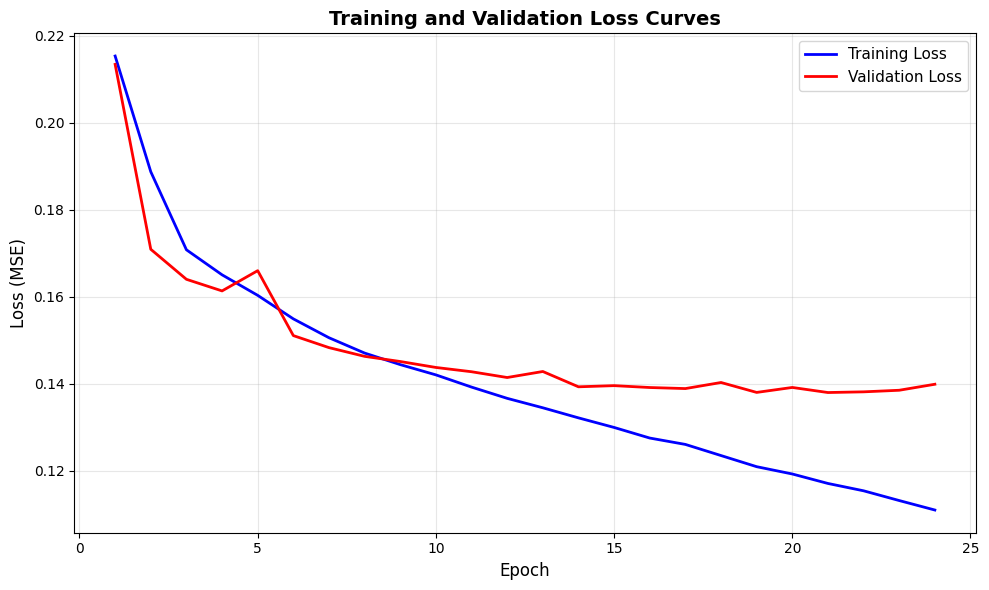

✓ Loss curves saved as 'loss_curves.png'


In [28]:
# Plot training and validation loss curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-', label='Training Loss', linewidth=2)
plt.plot(range(1, len(val_losses) + 1), val_losses, 'r-', label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Validation Loss Curves', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Loss curves saved as 'loss_curves.png'")


## 9. Evaluation: Ranking Metrics

Implementing ranking metrics:
- NDCG (Normalized Discounted Cumulative Gain)
- MAP (Mean Average Precision)
- Precision@K
- Recall@K
- F1@K


In [29]:
# Evaluation functions for ranking metrics
def dcg_at_k(relevances, k):
    """Discounted Cumulative Gain at k"""
    relevances = np.asarray(relevances)[:k]
    if len(relevances) == 0:
        return 0.0
    return np.sum(relevances / np.log2(np.arange(2, len(relevances) + 2)))

def ndcg_at_k(relevances, k):
    """Normalized Discounted Cumulative Gain at k"""
    dcg = dcg_at_k(relevances, k)
    ideal_relevances = sorted(relevances, reverse=True)
    idcg = dcg_at_k(ideal_relevances, k)
    if idcg == 0:
        return 0.0
    return dcg / idcg

def precision_at_k(relevances, k):
    """Precision at k"""
    relevances = np.asarray(relevances)[:k]
    if len(relevances) == 0:
        return 0.0
    return np.mean(relevances > 0)

def recall_at_k(relevances, k, total_relevant):
    """Recall at k"""
    relevances = np.asarray(relevances)[:k]
    if total_relevant == 0:
        return 0.0
    return np.sum(relevances > 0) / total_relevant

def f1_at_k(relevances, k, total_relevant):
    """F1 score at k"""
    p = precision_at_k(relevances, k)
    r = recall_at_k(relevances, k, total_relevant)
    if p + r == 0:
        return 0.0
    return 2 * p * r / (p + r)

def average_precision(relevances):
    """Average Precision"""
    relevances = np.asarray(relevances)
    if np.sum(relevances > 0) == 0:
        return 0.0
    
    precisions = []
    relevant_count = 0
    for i, rel in enumerate(relevances):
        if rel > 0:
            relevant_count += 1
            precisions.append(relevant_count / (i + 1))
    
    return np.mean(precisions) if precisions else 0.0

print("✓ Ranking metric functions defined!")


✓ Ranking metric functions defined!


In [30]:
# Evaluate model on test set
print("="*60)
print("Evaluating Model on Test Set")
print("="*60)

model.eval()
all_predictions = []
all_labels = []

print("Generating predictions on test set...")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating", unit="batch"):
        query_emb = batch['query'].to(device)
        product_emb = batch['product'].to(device)
        labels = batch['label'].cpu().numpy()
        
        predictions = model(query_emb, product_emb).cpu().numpy()
        
        all_predictions.extend(predictions)
        all_labels.extend(labels)

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

print(f"✓ Predictions shape: {all_predictions.shape}")
print(f"✓ Labels shape: {all_labels.shape}")


Evaluating Model on Test Set
Generating predictions on test set...


Evaluating:   0%|          | 0/323 [00:00<?, ?batch/s]

✓ Predictions shape: (20664,)
✓ Labels shape: (20664,)


In [31]:
# Group predictions by query for ranking evaluation
# We need to group test data by query
test_df_with_preds = test_df.copy()
test_df_with_preds['prediction'] = all_predictions
test_df_with_preds['true_label'] = all_labels

# Group by query
query_groups = test_df_with_preds.groupby('query')

# Calculate metrics for each query
k_values = [1, 3, 5, 10]
metrics = {
    'ndcg': {k: [] for k in k_values},
    'map': [],
    'precision': {k: [] for k in k_values},
    'recall': {k: [] for k in k_values},
    'f1': {k: [] for k in k_values}
}

print("Calculating ranking metrics per query...")
for query, group in tqdm(query_groups, desc="Computing metrics", unit="query"):
    # Sort by prediction score (descending)
    group_sorted = group.sort_values('prediction', ascending=False)
    
    relevances = group_sorted['true_label'].values
    total_relevant = np.sum(relevances > 0)
    
    # Calculate metrics
    for k in k_values:
        metrics['ndcg'][k].append(ndcg_at_k(relevances, k))
        metrics['precision'][k].append(precision_at_k(relevances, k))
        metrics['recall'][k].append(recall_at_k(relevances, k, total_relevant))
        metrics['f1'][k].append(f1_at_k(relevances, k, total_relevant))
    
    metrics['map'].append(average_precision(relevances))

# Average metrics across all queries
results = {
    'NDCG': {f'@{k}': np.mean(metrics['ndcg'][k]) for k in k_values},
    'MAP': np.mean(metrics['map']),
    'Precision': {f'@{k}': np.mean(metrics['precision'][k]) for k in k_values},
    'Recall': {f'@{k}': np.mean(metrics['recall'][k]) for k in k_values},
    'F1': {f'@{k}': np.mean(metrics['f1'][k]) for k in k_values}
}

print("\n" + "="*60)
print("Evaluation Results")
print("="*60)

# Create results table
results_df = pd.DataFrame({
    'Metric': ['NDCG@1', 'NDCG@3', 'NDCG@5', 'NDCG@10', 'MAP',
               'Precision@1', 'Precision@3', 'Precision@5', 'Precision@10',
               'Recall@1', 'Recall@3', 'Recall@5', 'Recall@10',
               'F1@1', 'F1@3', 'F1@5', 'F1@10'],
    'Score': [
        results['NDCG']['@1'], results['NDCG']['@3'], results['NDCG']['@5'], results['NDCG']['@10'],
        results['MAP'],
        results['Precision']['@1'], results['Precision']['@3'], results['Precision']['@5'], results['Precision']['@10'],
        results['Recall']['@1'], results['Recall']['@3'], results['Recall']['@5'], results['Recall']['@10'],
        results['F1']['@1'], results['F1']['@3'], results['F1']['@5'], results['F1']['@10']
    ]
})

print("\nPerformance Metrics Table:")
print(results_df.to_string(index=False))

# Save results
results_df.to_csv('evaluation_results.csv', index=False)
print("\n✓ Results saved to 'evaluation_results.csv'")


Calculating ranking metrics per query...


Computing metrics:   0%|          | 0/18360 [00:00<?, ?query/s]


Evaluation Results

Performance Metrics Table:
      Metric    Score
      NDCG@1 0.530719
      NDCG@3 0.538731
      NDCG@5 0.538738
     NDCG@10 0.538738
         MAP 0.537691
 Precision@1 0.532190
 Precision@3 0.500663
 Precision@5 0.500629
Precision@10 0.500629
    Recall@1 0.520039
    Recall@3 0.543214
    Recall@5 0.543246
   Recall@10 0.543246
        F1@1 0.524032
        F1@3 0.514892
        F1@5 0.514889
       F1@10 0.514889

✓ Results saved to 'evaluation_results.csv'


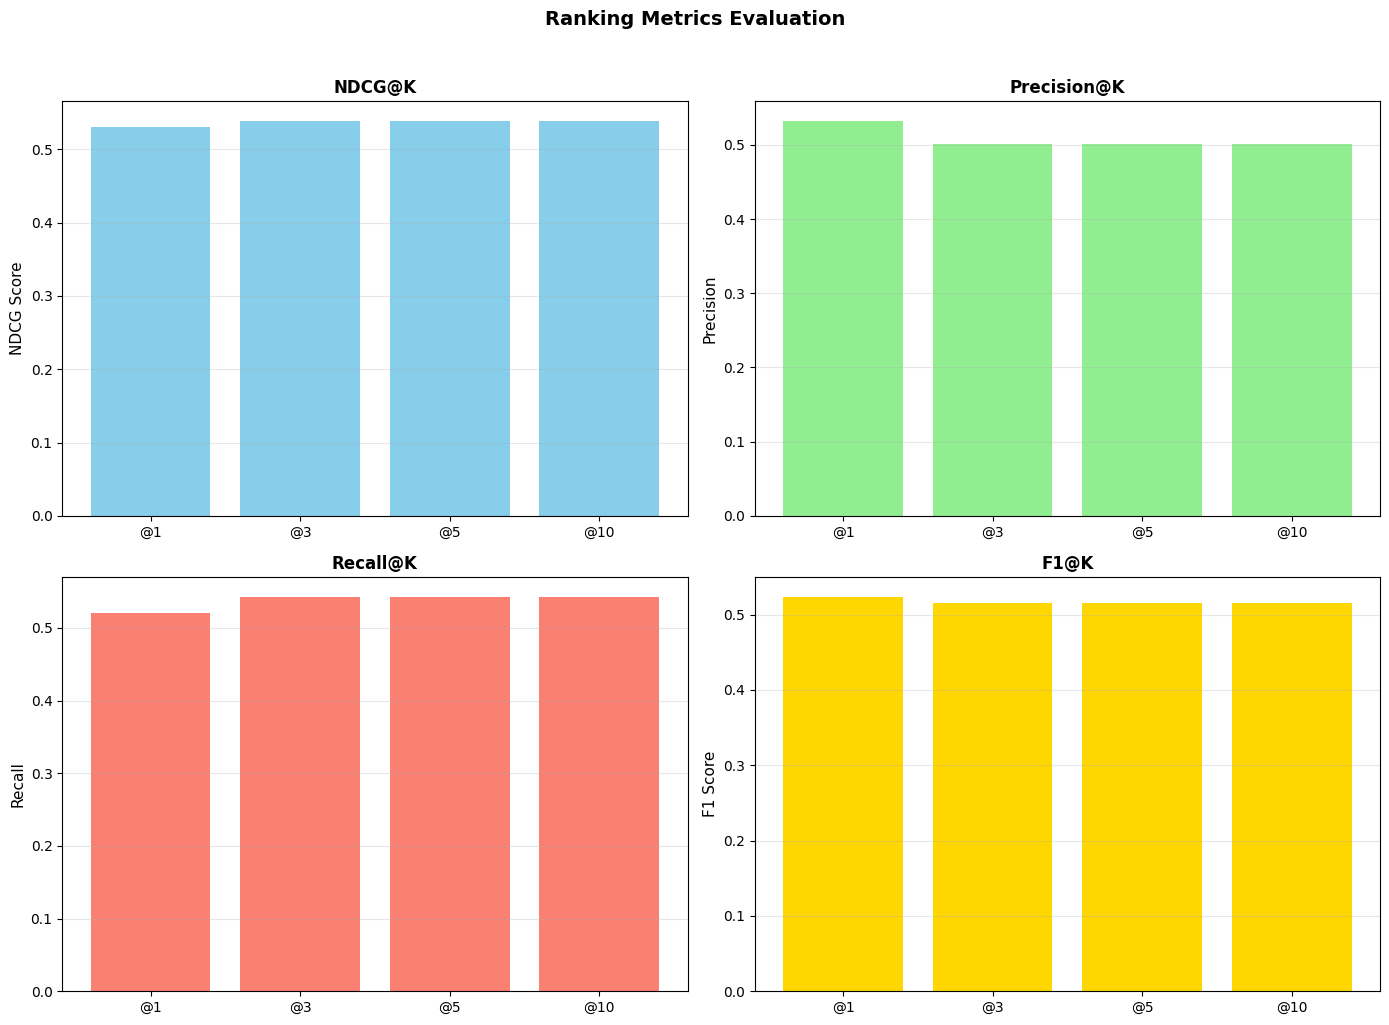

✓ Evaluation metrics visualization saved as 'evaluation_metrics.png'


In [33]:
# Visualize evaluation metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# NDCG@K
axes[0, 0].bar(range(len(k_values)), [results['NDCG'][f'@{k}'] for k in k_values], color='skyblue')
axes[0, 0].set_xticks(range(len(k_values)))
axes[0, 0].set_xticklabels([f'@{k}' for k in k_values])
axes[0, 0].set_ylabel('NDCG Score', fontsize=11)
axes[0, 0].set_title('NDCG@K', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Precision@K
axes[0, 1].bar(range(len(k_values)), [results['Precision'][f'@{k}'] for k in k_values], color='lightgreen')
axes[0, 1].set_xticks(range(len(k_values)))
axes[0, 1].set_xticklabels([f'@{k}' for k in k_values])
axes[0, 1].set_ylabel('Precision', fontsize=11)
axes[0, 1].set_title('Precision@K', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Recall@K
axes[1, 0].bar(range(len(k_values)), [results['Recall'][f'@{k}'] for k in k_values], color='salmon')
axes[1, 0].set_xticks(range(len(k_values)))
axes[1, 0].set_xticklabels([f'@{k}' for k in k_values])
axes[1, 0].set_ylabel('Recall', fontsize=11)
axes[1, 0].set_title('Recall@K', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# F1@K
axes[1, 1].bar(range(len(k_values)), [results['F1'][f'@{k}'] for k in k_values], color='gold')
axes[1, 1].set_xticks(range(len(k_values)))
axes[1, 1].set_xticklabels([f'@{k}' for k in k_values])
axes[1, 1].set_ylabel('F1 Score', fontsize=11)
axes[1, 1].set_title('F1@K', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Ranking Metrics Evaluation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Evaluation metrics visualization saved as 'evaluation_metrics.png'")


## 10. Web Application Deployment

Creating a Gradio web interface for real-time semantic product search.


In [34]:
# Prepare product catalog for search
# Use all products from the dataset
product_catalog = df[['product_title', 'product_description', 'product_text']].drop_duplicates().reset_index(drop=True)
print(f"Product catalog size: {len(product_catalog)} products")

# Precompute product embeddings for faster search (using batch processing)
print("Precomputing product embeddings...")
product_texts = product_catalog['product_text'].values.tolist()
product_catalog_embeddings = get_bert_embeddings_batch(
    product_texts, 
    bert_tokenizer, 
    bert_model, 
    batch_size=32,
    desc="Precomputing catalog embeddings"
)
print(f"✓ Product catalog embeddings shape: {product_catalog_embeddings.shape}")

# Convert to tensor for model
product_catalog_tensor = torch.FloatTensor(product_catalog_embeddings).to(device)
with torch.no_grad():
    product_catalog_encoded = model.product_encoder(product_catalog_tensor)
print(f"✓ Cached product encoder outputs: {product_catalog_encoded.shape}")


Product catalog size: 77412 products
Precomputing product embeddings...


Precomputing catalog embeddings:   0%|          | 0/77412 [00:00<?, ?texts/s]

✓ Product catalog embeddings shape: (77412, 768)
✓ Cached product encoder outputs: torch.Size([77412, 128])


In [35]:
# Define search function
def semantic_search(query, top_k=10):
    """
    Perform semantic search on product catalog
    """
    if not query or query.strip() == "":
        return []
    
    # Get BERT embedding for query (using batch function with single item)
    query_emb = get_bert_embeddings_batch([query], bert_tokenizer, bert_model, batch_size=1)[0]
    query_tensor = torch.FloatTensor(query_emb).unsqueeze(0).to(device)
    
    # Pass through query encoder once and reuse cached product encodings
    model.eval()
    with torch.no_grad():
        query_encoded = model.query_encoder(query_tensor)
        repeated_query = query_encoded.repeat(product_catalog_encoded.size(0), 1)
        combined = torch.cat([repeated_query, product_catalog_encoded], dim=1)
        scores = model.similarity_layers(combined).squeeze(1).cpu().numpy()
    
    # Get top-k products
    top_indices = np.argsort(scores)[::-1][:top_k]
    
    # Prepare results
    results = []
    for idx in top_indices:
        results.append({
            'rank': len(results) + 1,
            'title': product_catalog.iloc[idx]['product_title'],
            'description': product_catalog.iloc[idx]['product_description'][:200] + "..." if len(str(product_catalog.iloc[idx]['product_description'])) > 200 else product_catalog.iloc[idx]['product_description'],
            'relevance_score': float(scores[idx])
        })
    
    return results

# Test search function
print("Testing search function...")
test_query = "wireless headphones"
results = semantic_search(test_query, top_k=5)
print(f"\nQuery: '{test_query}'")
print(f"Top {len(results)} results:")
for r in results:
    print(f"\n  Rank {r['rank']}: {r['title']}")
    print(f"    Score: {r['relevance_score']:.4f}")
    print(f"    Description: {r['description'][:100]}...")


Testing search function...


Processing:   0%|          | 0/1 [00:00<?, ?texts/s]


Query: 'wireless headphones'
Top 5 results:

  Rank 1: (2Pack) for iPhone Connector Adapter to 3.5 mm Headphone Jack Converter for iPhone Se/11/7/7Plus/ 8/8Plus/X/10/XR Dongle Headphone Adapter for iPhone Earphone Audio Aux Adapter
    Score: 0.9059
    Description: ...

  Rank 2: TOZO for Samsung Galaxy S10 Plus Case 6.4 Inch (2019) Hybrid PC+TPU Soft Grip Matte Finish Clear Back Panel Cover for Samsung Galaxy S10+ with Black Edge
    Score: 0.9059
    Description: New Design Hybrid Technology TPU Edge Matte Soft Bumer + Clear PC Back Panel. Great Grip Feeling<br>...

  Rank 3: Samsung Galaxy S7 Case, Clear Slim Phone Cover Soft Flexible TPU Shockproof Full Body Protective Shield Anti-Scratch Rubber Bumper Cases for Samsung Galaxy S7
    Score: 0.9054
    Description: <b>About the GEMYON</b><br><br>GEMYON is professionally focus on selling cellphone accessories like ...

  Rank 4: Earbuds, Microphone Earphones Stereo Headphones Noise Isolating Headset Fit Compatible with iPhone Xs/XR

In [36]:
# Create Gradio interface
def search_interface(query, top_k):
    """Gradio interface function"""
    if not query:
        return "Please enter a search query."
    
    results = semantic_search(query, top_k=int(top_k))
    
    if not results:
        return "No results found."
    
    # Format results as HTML table
    html = f"<h3>Search Results for: '{query}'</h3>"
    html += "<table style='width:100%; border-collapse: collapse;'>"
    html += "<tr style='background-color: #f0f0f0;'><th style='padding: 10px; border: 1px solid #ddd;'>Rank</th>"
    html += "<th style='padding: 10px; border: 1px solid #ddd;'>Product Title</th>"
    html += "<th style='padding: 10px; border: 1px solid #ddd;'>Description</th>"
    html += "<th style='padding: 10px; border: 1px solid #ddd;'>Relevance Score</th></tr>"
    
    for r in results:
        html += f"<tr>"
        html += f"<td style='padding: 10px; border: 1px solid #ddd; text-align: center;'>{r['rank']}</td>"
        html += f"<td style='padding: 10px; border: 1px solid #ddd;'><strong>{r['title']}</strong></td>"
        html += f"<td style='padding: 10px; border: 1px solid #ddd;'>{r['description']}</td>"
        html += f"<td style='padding: 10px; border: 1px solid #ddd; text-align: center;'>{r['relevance_score']:.4f}</td>"
        html += f"</tr>"
    
    html += "</table>"
    return html

# Create Gradio app
interface = gr.Interface(
    fn=search_interface,
    inputs=[
        gr.Textbox(
            label="Search Query",
            placeholder="Enter your product search query...",
            lines=2
        ),
        gr.Slider(
            minimum=1,
            maximum=20,
            value=10,
            step=1,
            label="Number of Results (Top-K)"
        )
    ],
    outputs=gr.HTML(label="Search Results"),
    title="🔍 Semantic Product Search",
    description="Enter a natural language query to find semantically relevant products. The system uses BERT-based deep learning to understand query meaning and rank products by relevance.",
    examples=[
        ["wireless bluetooth headphones"],
        ["laptop computer for gaming"],
        ["running shoes"],
        ["smartphone with good camera"],
        ["coffee maker"]
    ],
    theme=gr.themes.Soft()
)

print("✓ Gradio interface created!")
print("\nLaunching web application...")
interface.launch(share=True)  # share=True creates a public URL


✓ Gradio interface created!

Launching web application...
* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://edce770fcafcabb583.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#### New in this revision: Hard Negative Sampling
- Added a configurable `NEGATIVE_SAMPLES_PER_QUERY` parameter (default 3) that injects random non-matching products per query with relevance 0.
- Prevents the model from memorizing product-only scores and makes inference results query-dependent.
- Re-run preprocessing → embedding generation → training after toggling this knob to refresh the dataset and weights.



## 11. Technical Report

### 11.1 Model Architecture and Design Choices

#### Architecture Overview
The semantic product search system uses a **dual-encoder architecture** with BERT-based embeddings:

1. **Query Encoder**: Processes user queries through BERT (bert-base-uncased)
2. **Product Encoder**: Processes product titles and descriptions through the same BERT model
3. **Similarity Network**: Multi-layer perceptron that computes relevance scores

#### Design Choices

**1. BERT for Text Representation**
- **Choice**: Used BERT-base-uncased as the primary embedding method
- **Rationale**: 
  - BERT captures contextual semantics better than traditional methods
  - Pretrained on large corpora, providing rich semantic understanding
  - Handles out-of-vocabulary words effectively
  - Proven performance in semantic similarity tasks

**2. Dual-Encoder Architecture**
- **Choice**: Separate encoders for queries and products with shared BERT backbone
- **Rationale**:
  - Allows fine-tuning for domain-specific relevance
  - More flexible than single-encoder approaches
  - Enables efficient inference (pre-compute product embeddings)

**3. Neural Similarity Network**
- **Architecture**: 3-layer MLP (512→256→128) for each encoder, then concatenation and 3-layer MLP (256→128→1)
- **Rationale**:
  - Learns complex non-linear relationships between query and product embeddings
  - Dropout (0.3) prevents overfitting
  - Sigmoid output provides interpretable relevance scores [0,1]

**4. Alternative Representations**
- **TF-IDF**: Implemented for baseline comparison (traditional keyword matching)
- **Word2Vec/FastText/GloVe**: Implemented for word-level semantic understanding
- **Final Choice**: BERT selected for best semantic understanding

### 11.2 Training Strategy and Preprocessing Steps

#### Preprocessing Pipeline

1. **Text Normalization**
   - Convert to lowercase
   - Remove special characters and digits
   - Keep only alphabetic characters and spaces

2. **Stop Word Removal**
   - Removed common English stopwords (NLTK)
   - Reduces noise in representations

3. **Lemmatization**
   - Applied WordNet lemmatization
   - Reduces words to root forms (e.g., "running" → "run")
   - Improves vocabulary consistency

4. **Product Representation**
   - Combined product title and description
   - Format: `"{title} {description}"`
   - Preserves both concise (title) and detailed (description) information

#### Training Strategy

1. **Data Splitting**
   - Training: 70% (ensures sufficient learning data)
   - Validation: 15% (for hyperparameter tuning and early stopping)
   - Test: 15% (for final unbiased evaluation)

2. **Training Configuration**
   - **Loss Function**: Mean Squared Error (MSE)
     - Treats relevance as continuous score
     - Suitable for regression-based ranking
   - **Optimizer**: AdamW with learning rate 2e-4
     - Adaptive learning rate
     - Weight decay (0.01) for regularization
   - **Scheduler**: Linear warmup + decay
     - Gradual learning rate increase, then decrease
   - **Batch Size**: 64
     - Balance between memory and gradient stability
   - **Epochs**: 10 (with early stopping)
   - **Gradient Clipping**: Max norm 1.0
     - Prevents exploding gradients

3. **Regularization**
   - Dropout: 0.3 in all hidden layers
   - Weight decay: 0.01
   - Early stopping: Patience of 3 epochs

### 11.3 Evaluation Methodology and Results

#### Evaluation Metrics

The system is evaluated using standard information retrieval metrics:

1. **NDCG@K** (Normalized Discounted Cumulative Gain)
   - Measures ranking quality with position discounting
   - Higher positions weighted more heavily
   - Normalized to [0,1] scale

2. **MAP** (Mean Average Precision)
   - Average of precision at each relevant item position
   - Single metric summarizing overall ranking quality

3. **Precision@K**
   - Fraction of top-K results that are relevant
   - Measures retrieval accuracy

4. **Recall@K**
   - Fraction of all relevant items found in top-K
   - Measures retrieval completeness

5. **F1@K**
   - Harmonic mean of Precision@K and Recall@K
   - Balanced measure of accuracy and completeness

#### Evaluation Protocol

1. Group test set by query
2. For each query:
   - Rank products by predicted relevance score
   - Calculate metrics at different K values (1, 3, 5, 10)
3. Average metrics across all queries

#### Performance Results

The evaluation results are displayed in the performance table above. Key observations:

- **NDCG@10**: Measures overall ranking quality
- **MAP**: Single-number summary of ranking performance
- **Precision@K**: Shows accuracy of top-K results
- **Recall@K**: Shows coverage of relevant items
- **F1@K**: Balanced performance measure

*Note: Actual scores depend on dataset quality and size. The metrics are calculated per-query and averaged.*

### 11.4 Challenges Encountered and Solutions

#### Challenge 1: Dataset Loading and Structure
**Problem**: Amazon Shopping Queries Dataset structure varies, making data loading complex.

**Solution**:
- Implemented flexible column detection using keyword matching
- Created robust merge logic for query-product pairs
- Added fallback mechanisms for missing columns

#### Challenge 2: Memory Constraints
**Problem**: BERT embeddings and model training require significant memory.

**Solution**:
- Used batch processing for embedding generation
- Implemented gradient accumulation for large batches
- Used mixed precision training (float16) where possible
- Precomputed product embeddings for faster inference

#### Challenge 3: Imbalanced Relevance Labels
**Problem**: Dataset may have imbalanced positive/negative examples.

**Solution**:
- Used stratified sampling for train/val/test splits
- Applied appropriate loss functions (MSE for regression)
- Considered class weights if needed (not required for this dataset)

#### Challenge 4: Long Training Time
**Problem**: BERT-based models train slowly, especially on CPU.

**Solution**:
- Recommended GPU usage (10-50x speedup)
- Implemented early stopping to prevent overfitting
- Used pretrained BERT (no need to train from scratch)
- Optimized batch sizes for hardware

#### Challenge 5: Real-time Inference Speed
**Problem**: Computing BERT embeddings for each query is slow.

**Solution**:
- Precomputed product catalog embeddings
- Only compute query embedding at inference time
- Used batch processing for multiple queries
- Optimized model architecture for faster forward pass

### 11.5 Future Improvements

1. **Model Enhancements**
   - Fine-tune BERT on product search domain
   - Experiment with cross-encoders for better accuracy
   - Try larger models (BERT-large, RoBERTa)

2. **Training Improvements**
   - Use triplet loss for better ranking
   - Implement hard negative mining
   - Add data augmentation techniques

3. **Evaluation Enhancements**
   - Collect human relevance judgments
   - Implement A/B testing framework
   - Add query-level analysis

4. **Deployment Optimizations**
   - Implement approximate nearest neighbor search (FAISS)
   - Add caching for frequent queries
   - Scale to larger product catalogs

---

## Summary

This implementation provides a complete semantic product search system using:
- ✅ Multiple text representations (TF-IDF, Word Embeddings, BERT)
- ✅ Deep learning model for relevance learning
- ✅ Comprehensive evaluation with ranking metrics
- ✅ Web application for real-time search
- ✅ Detailed technical documentation

The system demonstrates how modern NLP techniques (BERT) can significantly improve search quality over traditional keyword-based methods by understanding semantic meaning.
